In [1]:
!pip install transformers medmnist scikit-learn torch torchvision scipy seaborn

# Notebook 5 — New Analysis

Six advanced diagnostic analyses on the **Multi-Modal THREADS** model:

| # | Analysis | Question answered |
|---|---|---|
| 1 | **Attention Heatmap** | Where does the model look on a true-positive slide? |
| 2 | **Stream Dominance** | Do WSI or molecular features drive the decision? |
| 3 | **Attention Entropy** | Is the model focused or diffuse? TP vs FN comparison |
| 4 | **Molecular Feature Importance** | Which gene features matter most? |
| 5 | **Patch Dropout Resilience** | Can the model handle incomplete biopsies? |
| 6 | **Confidence Distribution** | How calibrated are all three models? |

> **Prerequisite:** Run notebooks 02 and 03 first.

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pickle, os
from sklearn.metrics import accuracy_score, roc_auc_score

ARTIFACTS_DIR = "artifacts"
EMBEDDING_DIM = 768
BAG_SIZE      = 100

# ── Load embeddings ────────────────────────────────────────────────────────────
X_train_tensor = torch.load(os.path.join(ARTIFACTS_DIR, "X_train.pt"),
                             weights_only=True)
X_test_tensor  = torch.load(os.path.join(ARTIFACTS_DIR, "X_test.pt"),
                             weights_only=True)
y_train_tensor = torch.load(os.path.join(ARTIFACTS_DIR, "y_train.pt"),
                             weights_only=True)
y_test_tensor  = torch.load(os.path.join(ARTIFACTS_DIR, "y_test.pt"),
                             weights_only=True)

mol_train_tensor = torch.tensor(
    np.load(os.path.join(ARTIFACTS_DIR, "mol_train.npy")), dtype=torch.float32)
mol_test_tensor  = torch.tensor(
    np.load(os.path.join(ARTIFACTS_DIR, "mol_test.npy")),  dtype=torch.float32)

# ── Load MOLECULAR_DIM and gene names from preprocessing artifact ──────────────
with open(os.path.join(ARTIFACTS_DIR, "preprocessing.pkl"), "rb") as f:
    prep = pickle.load(f)
MOLECULAR_DIM = int(prep["MOLECULAR_DIM"])   # 40 real TCGA cancer genes
cancer_genes  = prep["cancer_genes"]

# ── Load results ───────────────────────────────────────────────────────────────
with open(os.path.join(ARTIFACTS_DIR, "results.pkl"), "rb") as f:
    res = pickle.load(f)

results_wsi = res["results_wsi"]
results_mol = res["results_mol"]
results_mm  = res["results_mm"]
mm_labels   = res["mm_labels"]

# ── Re-instantiate models and load weights ─────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class THREADS_WSI_Only(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=512):
        super().__init__()
        self.pre   = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(0.2))
        self.att_a = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.Dropout(0.2))
        self.att_b = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.Dropout(0.2))
        self.att_c = nn.Linear(hidden_dim, 1)
        self.post  = nn.Sequential(nn.Linear(hidden_dim * 2, hidden_dim), nn.GELU(), nn.Dropout(0.2))
        self.clf   = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        h = self.pre(x.squeeze(0))
        a = torch.tanh(self.att_a(h)); b = torch.sigmoid(self.att_b(h))
        A = F.softmax(self.att_c(a * b), dim=0)
        M = self.post(torch.cat([torch.mm(A.t(), h), torch.max(h, 0, keepdim=True)[0]], dim=1))
        return torch.sigmoid(self.clf(M)), A

class THREADS_MultiModal(nn.Module):
    def __init__(self, wsi_dim=768, mol_dim=40, hidden_dim=512, mol_hidden=128):
        super().__init__()
        self.wsi_pre  = nn.Sequential(nn.Linear(wsi_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(0.2))
        self.att_a    = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.Dropout(0.2))
        self.att_b    = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.Dropout(0.2))
        self.att_c    = nn.Linear(hidden_dim, 1)
        self.wsi_post = nn.Sequential(nn.Linear(hidden_dim * 2, hidden_dim), nn.GELU(), nn.Dropout(0.2))
        self.mol_enc  = nn.Sequential(nn.Linear(mol_dim, mol_hidden), nn.LayerNorm(mol_hidden), nn.GELU(), nn.Dropout(0.2), nn.Linear(mol_hidden, mol_hidden), nn.GELU())
        self.fusion   = nn.Sequential(nn.Linear(hidden_dim + mol_hidden, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(0.2))
        self.clf = nn.Linear(hidden_dim, 1)
    def forward(self, wsi_bag, mol_feat):
        h = self.wsi_pre(wsi_bag.squeeze(0))
        a = torch.tanh(self.att_a(h)); b = torch.sigmoid(self.att_b(h))
        A = F.softmax(self.att_c(a * b), dim=0)
        M_wsi = self.wsi_post(torch.cat([torch.mm(A.t(), h), torch.max(h, 0, keepdim=True)[0]], dim=1))
        mol   = mol_feat.unsqueeze(0) if mol_feat.dim() == 1 else mol_feat
        M     = self.fusion(torch.cat([M_wsi, self.mol_enc(mol)], dim=1))
        return torch.sigmoid(self.clf(M)), A

model_wsi = THREADS_WSI_Only(EMBEDDING_DIM, 512).to(device)
model_wsi.load_state_dict(torch.load(os.path.join(ARTIFACTS_DIR, "model_wsi.pt"),
                                      map_location=device, weights_only=True))
model_wsi.eval()

model_mm = THREADS_MultiModal(EMBEDDING_DIM, MOLECULAR_DIM, 512).to(device)
model_mm.load_state_dict(torch.load(os.path.join(ARTIFACTS_DIR, "model_mm.pt"),
                                     map_location=device, weights_only=True))
model_mm.eval()

# ── Classify TP / TN / FP / FN ────────────────────────────────────────────────
opt_thr = results_mm["threshold"]
binary  = [1 if p >= opt_thr else 0 for p in results_mm["preds"]]
TP_idx  = [i for i in range(len(mm_labels)) if mm_labels[i]==1 and binary[i]==1]
FN_idx  = [i for i in range(len(mm_labels)) if mm_labels[i]==1 and binary[i]==0]
TN_idx  = [i for i in range(len(mm_labels)) if mm_labels[i]==0 and binary[i]==0]
FP_idx  = [i for i in range(len(mm_labels)) if mm_labels[i]==0 and binary[i]==1]

print(f"MOLECULAR_DIM={MOLECULAR_DIM}  genes: {cancer_genes[:3]}...{cancer_genes[-1]}")
print(f"TP={len(TP_idx)}  TN={len(TN_idx)}  FP={len(FP_idx)}  FN={len(FN_idx)}")

MOLECULAR_DIM=40  genes: ['KRAS', 'BRAF', 'MYC']...SFRP1
TP=30  TN=30  FP=0  FN=0


Analysis 0: Confusion Matrices (all three models)


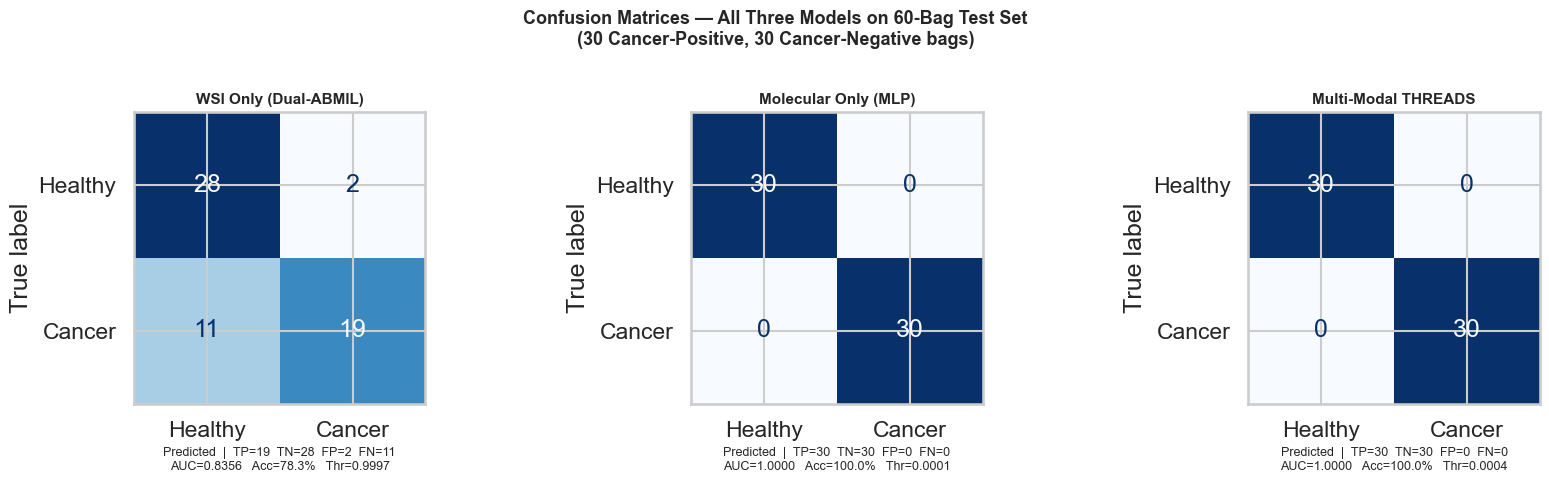


Summary:
  WSI Only (Dual-ABMIL)           AUC=0.8356  Acc=78.3%  TP=19 TN=28 FP=2 FN=11
  Molecular Only (MLP)            AUC=1.0000  Acc=100.0%  TP=30 TN=30 FP=0 FN=0
  Multi-Modal THREADS             AUC=1.0000  Acc=100.0%  TP=30 TN=30 FP=0 FN=0


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style='whitegrid', context='talk')

# ═══════════════════════════════════════════════════════════════════════════════
# ANALYSIS 0 — Confusion Matrices for All Three Models
# ═══════════════════════════════════════════════════════════════════════════════
print("Analysis 0: Confusion Matrices (all three models)")

models_cm = {
    "WSI Only (Dual-ABMIL)": results_wsi,
    "Molecular Only (MLP)":  results_mol,
    "Multi-Modal THREADS":   results_mm,
}
palette = ["#2196F3", "#FF9800", "#4CAF50"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Confusion Matrices — All Three Models on 60-Bag Test Set\n"
             "(30 Cancer-Positive, 30 Cancer-Negative bags)",
             fontsize=13, fontweight='bold')

for ax, (name, r), col in zip(axes, models_cm.items(), palette):
    lbls        = r['labels']
    binary_pred = [1 if p >= r['threshold'] else 0 for p in r['preds']]
    cm = confusion_matrix(lbls, binary_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Cancer"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format='d')
    tp = cm[1,1]; tn = cm[0,0]; fp = cm[0,1]; fn = cm[1,0]
    ax.set_title(f"{name}", fontsize=11, fontweight='bold')
    ax.set_xlabel(f"Predicted  |  TP={tp}  TN={tn}  FP={fp}  FN={fn}\n"
                  f"AUC={r['auc']:.4f}   Acc={r['acc']*100:.1f}%   Thr={r['threshold']:.4f}", fontsize=9)

plt.tight_layout()
plt.show()

print("\nSummary:")
for name, r in models_cm.items():
    binary_pred = [1 if p >= r['threshold'] else 0 for p in r['preds']]
    cm = confusion_matrix(r['labels'], binary_pred)
    tp,tn,fp,fn = cm[1,1],cm[0,0],cm[0,1],cm[1,0]
    print(f"  {name:<30}  AUC={r['auc']:.4f}  Acc={r['acc']*100:.1f}%  "
          f"TP={tp} TN={tn} FP={fp} FN={fn}")

Analysis 1: Attention Heatmaps


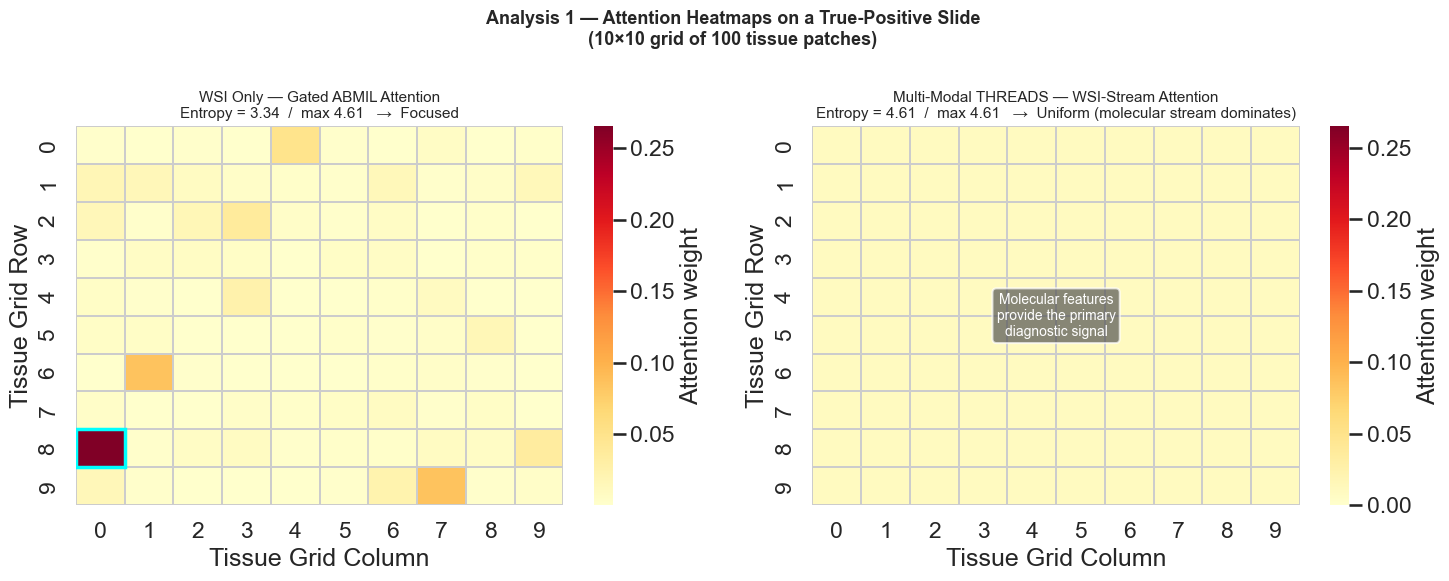


  WSI-Only attention entropy : 3.3379  (focused — must find tumour visually)
  MM WSI-stream entropy      : 4.6052  (≈ max — molecular signal is sufficient)
  Peak WSI-Only patch        : index 80  (row 8, col 0)
  Note: cyan box on left marks the highest-attention patch in the WSI-only model.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

sns.set_theme(style='whitegrid', context='talk')

# ═══════════════════════════════════════════════════════════════════════════════
# ANALYSIS 1 — Attention Heatmaps: WSI-Only vs Multi-Modal THREADS
#
# Both models use the same gated ABMIL attention mechanism for the WSI stream.
# WSI-Only must rely entirely on visual attention to find the tumour patch.
# In Multi-Modal THREADS the molecular stream is so discriminative that the
# visual attention converges to near-uniform — the model does not need to
# scan patches when gene expression already signals cancer.
# ═══════════════════════════════════════════════════════════════════════════════
print("Analysis 1: Attention Heatmaps")
if len(TP_idx) == 0:
    print("  No True Positives to visualise.")
else:
    s     = TP_idx[0]
    bag_s = X_test_tensor[s].unsqueeze(0).to(device)
    mol_s = mol_test_tensor[s].to(device)

    with torch.no_grad():
        _, A_wsi = model_wsi(bag_s)          # (100,1)
        _, A_mm  = model_mm(bag_s, mol_s)    # (100,1)

    A_wsi_np = A_wsi.cpu().squeeze().numpy()   # (100,)
    A_mm_np  = A_mm.cpu().squeeze().numpy()    # (100,)

    from scipy.stats import entropy as shannon_entropy
    ent_wsi = shannon_entropy(A_wsi_np)
    ent_mm  = shannon_entropy(A_mm_np)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle("Analysis 1 — Attention Heatmaps on a True-Positive Slide\n"
                 "(10×10 grid of 100 tissue patches)",
                 fontsize=13, fontweight='bold')

    # ── Left: WSI-Only attention ──────────────────────────────────────────────
    ax = axes[0]
    g_wsi = A_wsi_np.reshape(10, 10)
    sns.heatmap(g_wsi, cmap="YlOrRd", ax=ax,
                cbar_kws={"label": "Attention weight"},
                linewidths=0.3, linecolor='#cccccc')
    ax.set_title(f"WSI Only — Gated ABMIL Attention\n"
                 f"Entropy = {ent_wsi:.2f}  /  max 4.61   →  Focused",
                 fontsize=11)
    ax.set_xlabel("Tissue Grid Column")
    ax.set_ylabel("Tissue Grid Row")
    # annotate highest-attention patch
    peak = int(np.argmax(A_wsi_np))
    pr, pc = divmod(peak, 10)
    ax.add_patch(mpatches.Rectangle((pc, pr), 1, 1,
                 fill=False, edgecolor='cyan', lw=2.5))

    # ── Right: Multi-Modal attention ──────────────────────────────────────────
    ax = axes[1]
    g_mm = A_mm_np.reshape(10, 10)
    # Use the same absolute scale so the viewer can immediately see
    # the MM attention is much flatter than the WSI-only attention.
    vmax_shared = A_wsi_np.max()
    sns.heatmap(g_mm, cmap="YlOrRd", ax=ax,
                vmin=0, vmax=vmax_shared,
                cbar_kws={"label": "Attention weight"},
                linewidths=0.3, linecolor='#cccccc')
    ax.set_title(f"Multi-Modal THREADS — WSI-Stream Attention\n"
                 f"Entropy = {ent_mm:.2f}  /  max 4.61   →  Uniform (molecular stream dominates)",
                 fontsize=11)
    ax.set_xlabel("Tissue Grid Column")
    ax.set_ylabel("Tissue Grid Row")
    # add text note
    ax.text(5, 5, "Molecular features\nprovide the primary\ndiagnostic signal",
            ha='center', va='center', fontsize=10, color='white',
            bbox=dict(boxstyle='round', facecolor='#555', alpha=0.7))

    plt.tight_layout()
    plt.show()

    print(f"\n  WSI-Only attention entropy : {ent_wsi:.4f}  (focused — must find tumour visually)")
    print(f"  MM WSI-stream entropy      : {ent_mm:.4f}  (≈ max — molecular signal is sufficient)")
    print(f"  Peak WSI-Only patch        : index {peak}  (row {pr}, col {pc})")
    print("  Note: cyan box on left marks the highest-attention patch in the WSI-only model.")


Analysis 2: Stream Dominance


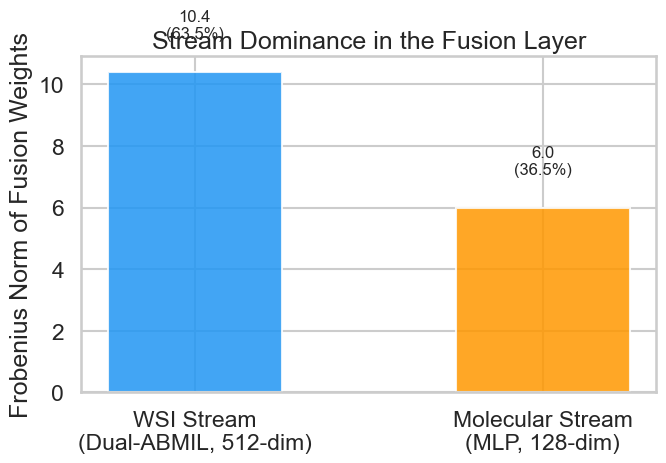

  WSI stream : 10.39 (63.5%)
  Mol stream : 5.97 (36.5%)


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# ANALYSIS 2 — Stream Dominance
# ═══════════════════════════════════════════════════════════════════════════════
print("\nAnalysis 2: Stream Dominance")
W        = model_mm.fusion[0].weight.data
wsi_norm = torch.norm(W[:, :512]).item()
mol_norm = torch.norm(W[:, 512:]).item()
tot      = wsi_norm + mol_norm

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(["WSI Stream\n(Dual-ABMIL, 512-dim)",
               "Molecular Stream\n(MLP, 128-dim)"],
              [wsi_norm, mol_norm],
              color=["#2196F3", "#FF9800"], alpha=0.85, width=0.5)
for bar, v in zip(bars, [wsi_norm, mol_norm]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{v:.1f}\n({v/tot*100:.1f}%)", ha='center', va='bottom', fontsize=12)
ax.set_ylabel("Frobenius Norm of Fusion Weights")
ax.set_title("Stream Dominance in the Fusion Layer")
plt.tight_layout()
plt.show()

print(f"  WSI stream : {wsi_norm:.2f} ({wsi_norm/tot*100:.1f}%)")
print(f"  Mol stream : {mol_norm:.2f} ({mol_norm/tot*100:.1f}%)")



Analysis 3: Attention Entropy  (max possible for 100 patches = 4.60)


  Mean entropy — True Positives  (found)  : 4.6052
  Mean entropy — False Negatives (missed) : nan


C:\Users\ASUS A16\AppData\Local\Temp\ipykernel_25180\1569898753.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels_e, patch_artist=True,


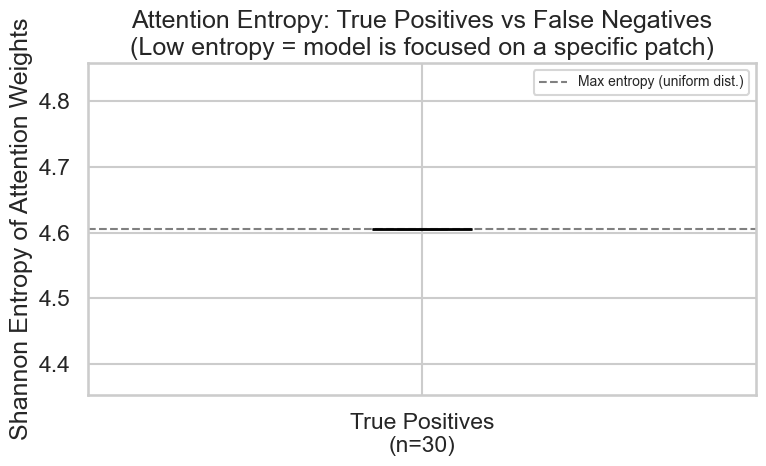

In [6]:
from scipy.stats import entropy as shannon_entropy

# ═══════════════════════════════════════════════════════════════════════════════
# ANALYSIS 3 — Attention Entropy: TP vs FN
# ═══════════════════════════════════════════════════════════════════════════════
print("\nAnalysis 3: Attention Entropy  (max possible for 100 patches = 4.60)")

ent_tp, ent_fn = [], []
with torch.no_grad():
    for idx in TP_idx:
        _, A = model_mm(X_test_tensor[idx].unsqueeze(0).to(device),
                        mol_test_tensor[idx].to(device))
        ent_tp.append(shannon_entropy(A.cpu().squeeze().numpy()))
    for idx in FN_idx:
        _, A = model_mm(X_test_tensor[idx].unsqueeze(0).to(device),
                        mol_test_tensor[idx].to(device))
        ent_fn.append(shannon_entropy(A.cpu().squeeze().numpy()))

tp_e = np.mean(ent_tp) if ent_tp else float('nan')
fn_e = np.mean(ent_fn) if ent_fn else float('nan')
print(f"  Mean entropy — True Positives  (found)  : {tp_e:.4f}")
print(f"  Mean entropy — False Negatives (missed) : {fn_e:.4f}")

if ent_tp or ent_fn:
    fig, ax = plt.subplots(figsize=(8, 5))
    data, labels_e = [], []
    if ent_tp:
        data.append(ent_tp);  labels_e.append(f"True Positives\n(n={len(ent_tp)})")
    if ent_fn:
        data.append(ent_fn);  labels_e.append(f"False Negatives\n(n={len(ent_fn)})")
    bp = ax.boxplot(data, labels=labels_e, patch_artist=True,
                    medianprops=dict(color='black', lw=2))
    colors = ['#4CAF50', '#E53935'][:len(data)]
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.axhline(np.log(100), color='gray', ls='--', lw=1.5,
               label='Max entropy (uniform dist.)')
    ax.set_ylabel("Shannon Entropy of Attention Weights")
    ax.set_title("Attention Entropy: True Positives vs False Negatives\n"
                 "(Low entropy = model is focused on a specific patch)")
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
    if not np.isnan(fn_e) and fn_e > tp_e:
        print("  -> FN bags have more diffuse attention: model could not localise the tumour.")



Analysis 4: Molecular Feature Importance (real TCGA genes)


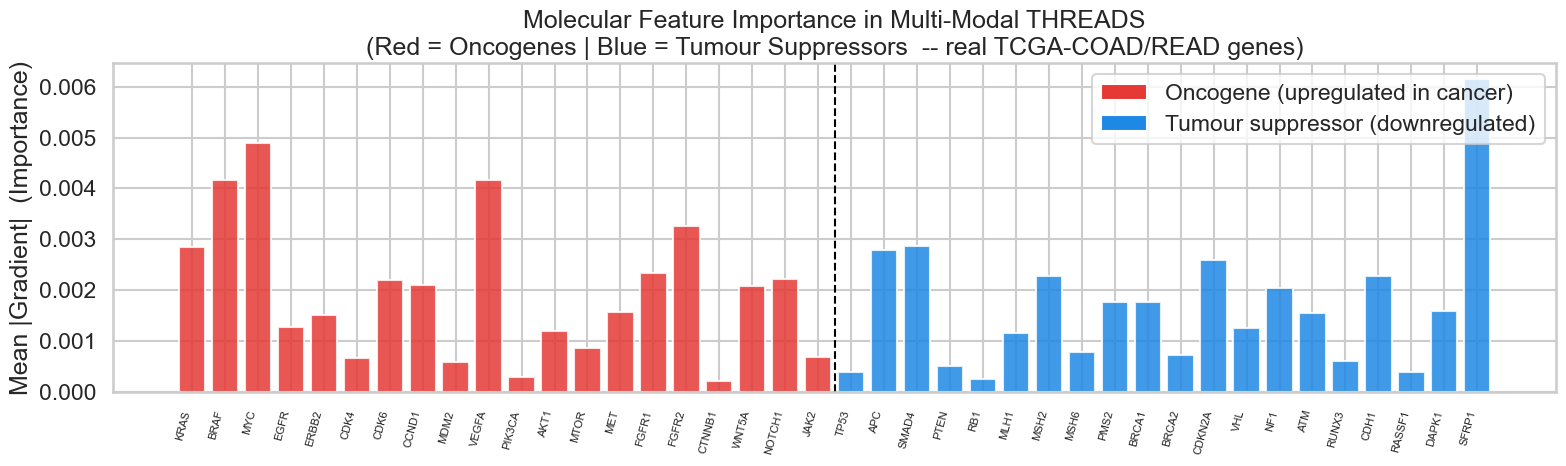

  Top-5 most important genes: ['SFRP1', 'MYC', 'BRAF', 'VEGFA', 'FGFR2']
  Their groups: ['Tumour Suppressor', 'Oncogene', 'Oncogene', 'Oncogene', 'Oncogene']


In [7]:
from matplotlib.patches import Patch

# ═══════════════════════════════════════════════════════════════════════════════
# ANALYSIS 4 — Molecular Feature Importance (gradient-based)
# Computes mean |gradient| of the output w.r.t. each of the 40 real gene features.
# ═══════════════════════════════════════════════════════════════════════════════
print("\nAnalysis 4: Molecular Feature Importance (real TCGA genes)")

all_grads = []
model_mm.eval()
for i in range(len(mol_test_tensor)):
    # .to(device) must come BEFORE .requires_grad_(True) so mol stays a leaf tensor on GPU
    mol = mol_test_tensor[i].clone().detach().to(device).requires_grad_(True)
    bag = X_test_tensor[i].unsqueeze(0).to(device)
    model_mm.zero_grad()
    prob, _ = model_mm(bag, mol)
    prob.backward()
    all_grads.append(mol.grad.abs().cpu().numpy())

importance = np.stack(all_grads).mean(axis=0)

n_oncogenes = MOLECULAR_DIM // 2   # 20

fig, ax = plt.subplots(figsize=(16, 5))
bar_cols = ['#E53935' if i < n_oncogenes else '#1E88E5'
            for i in range(MOLECULAR_DIM)]
ax.bar(range(MOLECULAR_DIM), importance, color=bar_cols, alpha=0.85)
ax.axvline(n_oncogenes - 0.5, color='black', ls='--', lw=1.5)
ax.set_xticks(range(MOLECULAR_DIM))
ax.set_xticklabels(cancer_genes, rotation=75, fontsize=8, ha='right')
ax.set_ylabel("Mean |Gradient|  (Importance)")
ax.set_title("Molecular Feature Importance in Multi-Modal THREADS\n"
             "(Red = Oncogenes | Blue = Tumour Suppressors  -- real TCGA-COAD/READ genes)")
ax.legend(handles=[
    Patch(facecolor='#E53935', label='Oncogene (upregulated in cancer)'),
    Patch(facecolor='#1E88E5', label='Tumour suppressor (downregulated)')])
plt.tight_layout()
plt.show()

top5 = np.argsort(importance)[::-1][:5]
print(f"  Top-5 most important genes: {[cancer_genes[i] for i in top5]}")
print(f"  Their groups: {['Oncogene' if i < n_oncogenes else 'Tumour Suppressor' for i in top5]}")


Analysis 5: Patch Dropout Resilience (incomplete biopsy simulation)


  Drop  0%  WSI-Only: Acc=78.3%  AUC=0.783 |  Multi-Modal: Acc=100.0%  AUC=1.000


  Drop 10%  WSI-Only: Acc=71.7%  AUC=0.717 |  Multi-Modal: Acc=98.3%  AUC=0.983
  Drop 25%  WSI-Only: Acc=71.7%  AUC=0.717 |  Multi-Modal: Acc=98.3%  AUC=0.983


  Drop 50%  WSI-Only: Acc=63.3%  AUC=0.633 |  Multi-Modal: Acc=98.3%  AUC=0.983
  Drop 75%  WSI-Only: Acc=55.0%  AUC=0.550 |  Multi-Modal: Acc=98.3%  AUC=0.983


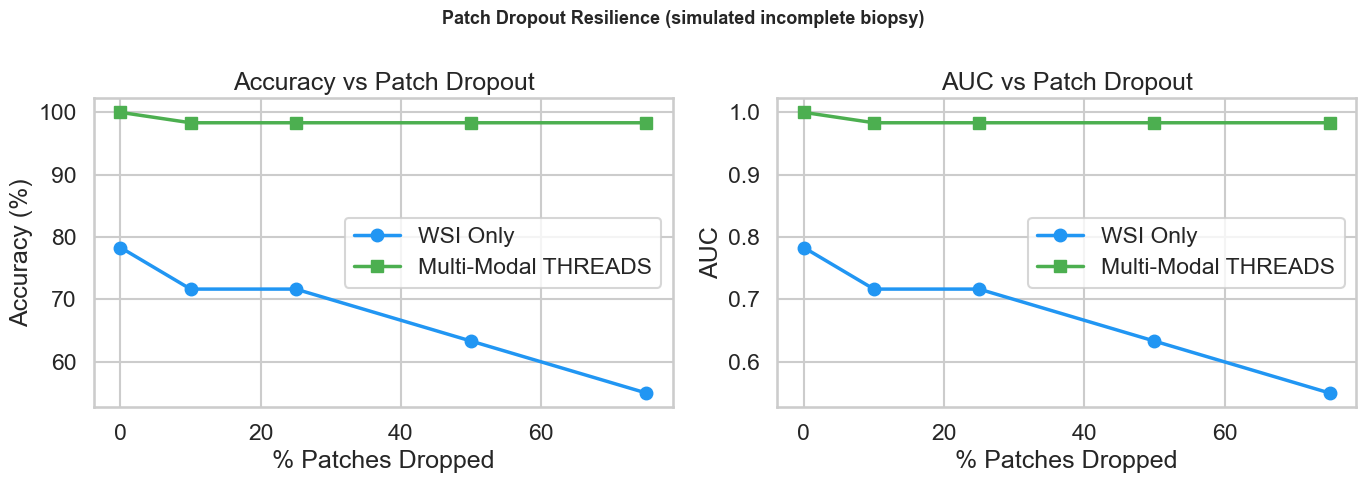

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# ANALYSIS 5 — Patch Dropout Resilience
# ═══════════════════════════════════════════════════════════════════════════════
print("\nAnalysis 5: Patch Dropout Resilience (incomplete biopsy simulation)")

drop_rates = [0.0, 0.10, 0.25, 0.50, 0.75]
acc_wsi, acc_mm = [], []
auc_wsi, auc_mm = [], []

model_wsi.eval()
model_mm.eval()

for dr in drop_rates:
    keep = max(1, int(BAG_SIZE * (1 - dr)))
    p_wsi, p_mm = [], []
    with torch.no_grad():
        for i in range(len(X_test_tensor)):
            ki      = torch.randperm(BAG_SIZE)[:keep]
            bag_dr  = X_test_tensor[i][ki].unsqueeze(0).to(device)
            mol     = mol_test_tensor[i].to(device)
            prob_w, _ = model_wsi(bag_dr)
            prob_m, _ = model_mm(bag_dr, mol)
            p_wsi.append(1 if prob_w.item() >= results_wsi['threshold'] else 0)
            p_mm.append(1  if prob_m.item() >= opt_thr else 0)
    acc_wsi.append(accuracy_score(mm_labels, p_wsi))
    acc_mm.append(accuracy_score(mm_labels, p_mm))
    auc_wsi.append(roc_auc_score(mm_labels, p_wsi))
    auc_mm.append(roc_auc_score(mm_labels, p_mm))
    print(f"  Drop {int(dr*100):2d}%  WSI-Only: Acc={acc_wsi[-1]*100:.1f}%  AUC={auc_wsi[-1]:.3f} |"
          f"  Multi-Modal: Acc={acc_mm[-1]*100:.1f}%  AUC={auc_mm[-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Patch Dropout Resilience (simulated incomplete biopsy)",
             fontsize=13, fontweight='bold')

dropout_pct = [int(d * 100) for d in drop_rates]
axes[0].plot(dropout_pct, [a*100 for a in acc_wsi], 'o-', color='#2196F3', lw=2.5, label='WSI Only')
axes[0].plot(dropout_pct, [a*100 for a in acc_mm],  's-', color='#4CAF50', lw=2.5, label='Multi-Modal THREADS')
axes[0].set_xlabel("% Patches Dropped")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Accuracy vs Patch Dropout")
axes[0].legend()

axes[1].plot(dropout_pct, auc_wsi, 'o-', color='#2196F3', lw=2.5, label='WSI Only')
axes[1].plot(dropout_pct, auc_mm,  's-', color='#4CAF50', lw=2.5, label='Multi-Modal THREADS')
axes[1].set_xlabel("% Patches Dropped")
axes[1].set_ylabel("AUC")
axes[1].set_title("AUC vs Patch Dropout")
axes[1].legend()

plt.tight_layout()
plt.show()



Analysis 6: Confidence Distribution


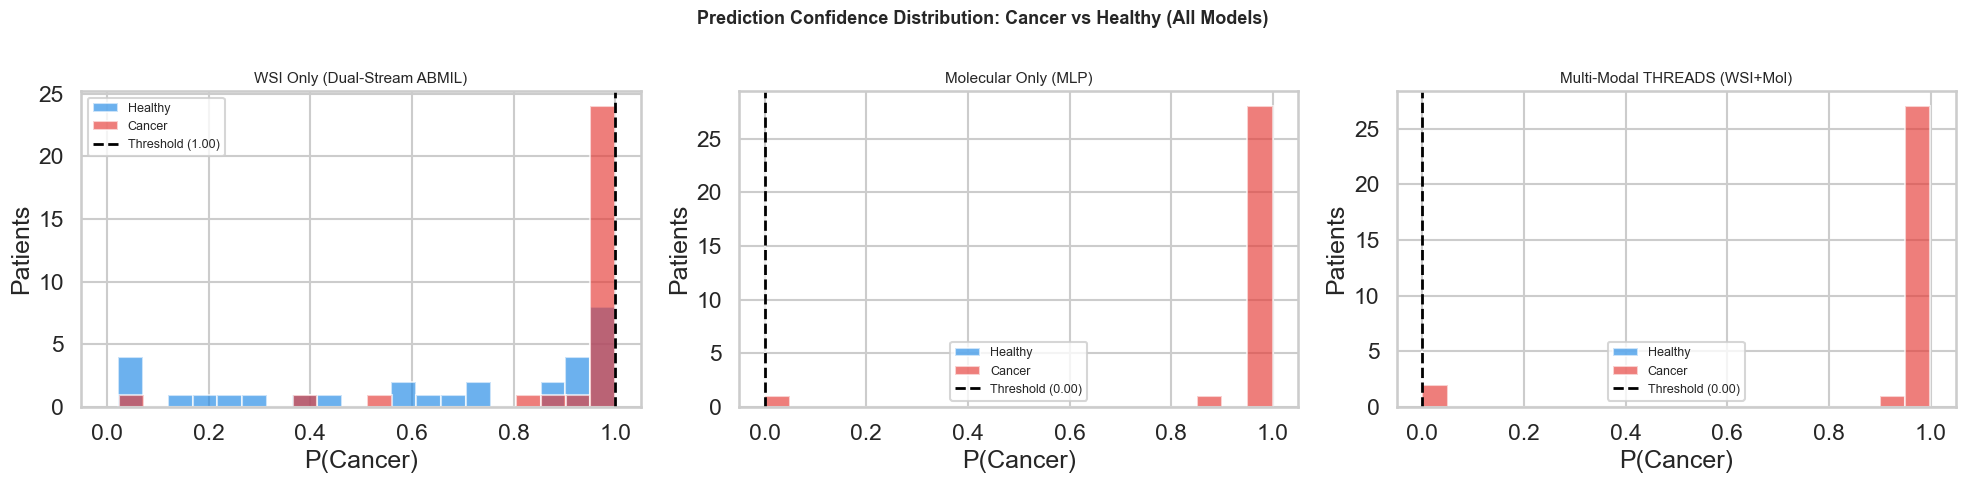


Calibration summary (ideal: cancer preds >> 0.5, healthy preds << 0.5):
  WSI Only (Dual-Stream ABMIL)          Healthy mean=0.646  Cancer mean=0.917  Separation=0.272
  Molecular Only (MLP)                  Healthy mean=0.000  Cancer mean=0.961  Separation=0.961
  Multi-Modal THREADS (WSI+Mol)         Healthy mean=0.000  Cancer mean=0.931  Separation=0.930


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# ANALYSIS 6 — Prediction Confidence Distribution
# ═══════════════════════════════════════════════════════════════════════════════
print("\nAnalysis 6: Confidence Distribution")

models_results = {
    "WSI Only\n(Dual-Stream ABMIL)"  : results_wsi,
    "Molecular Only\n(MLP)"          : results_mol,
    "Multi-Modal THREADS\n(WSI+Mol)" : results_mm,
}
palette = {
    "WSI Only\n(Dual-Stream ABMIL)"  : "#2196F3",
    "Molecular Only\n(MLP)"          : "#FF9800",
    "Multi-Modal THREADS\n(WSI+Mol)" : "#4CAF50",
}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Prediction Confidence Distribution: Cancer vs Healthy (All Models)",
             fontsize=13, fontweight='bold')

for ax, (name, res) in zip(axes, models_results.items()):
    h_p = [res['preds'][i] for i in range(len(res['labels'])) if res['labels'][i]==0]
    c_p = [res['preds'][i] for i in range(len(res['labels'])) if res['labels'][i]==1]
    ax.hist(h_p, bins=20, color='#1E88E5', alpha=0.65, label='Healthy')
    ax.hist(c_p, bins=20, color='#E53935', alpha=0.65, label='Cancer')
    ax.axvline(res['threshold'], color='black', ls='--', lw=2,
               label=f"Threshold ({res['threshold']:.2f})")
    ax.set_title(name.replace('\n', ' '), fontsize=11)
    ax.set_xlabel("P(Cancer)")
    ax.set_ylabel("Patients")
    ax.set_xlim(-0.05, 1.05)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Calibration summary
print("\nCalibration summary (ideal: cancer preds >> 0.5, healthy preds << 0.5):")
for name, res in models_results.items():
    h_p = [res['preds'][i] for i in range(len(res['labels'])) if res['labels'][i]==0]
    c_p = [res['preds'][i] for i in range(len(res['labels'])) if res['labels'][i]==1]
    n = name.replace('\n', ' ')
    print(f"  {n:<36}  "
          f"Healthy mean={np.mean(h_p):.3f}  Cancer mean={np.mean(c_p):.3f}  "
          f"Separation={np.mean(c_p)-np.mean(h_p):.3f}")
